In [1]:
%matplotlib notebook

In [1]:
from dynrdpg import DynamicRDPG
from dynrdpg.datasets import simulate_network_rw, simulate_network_gp

0.09832857142857145


<IPython.core.display.Javascript object>


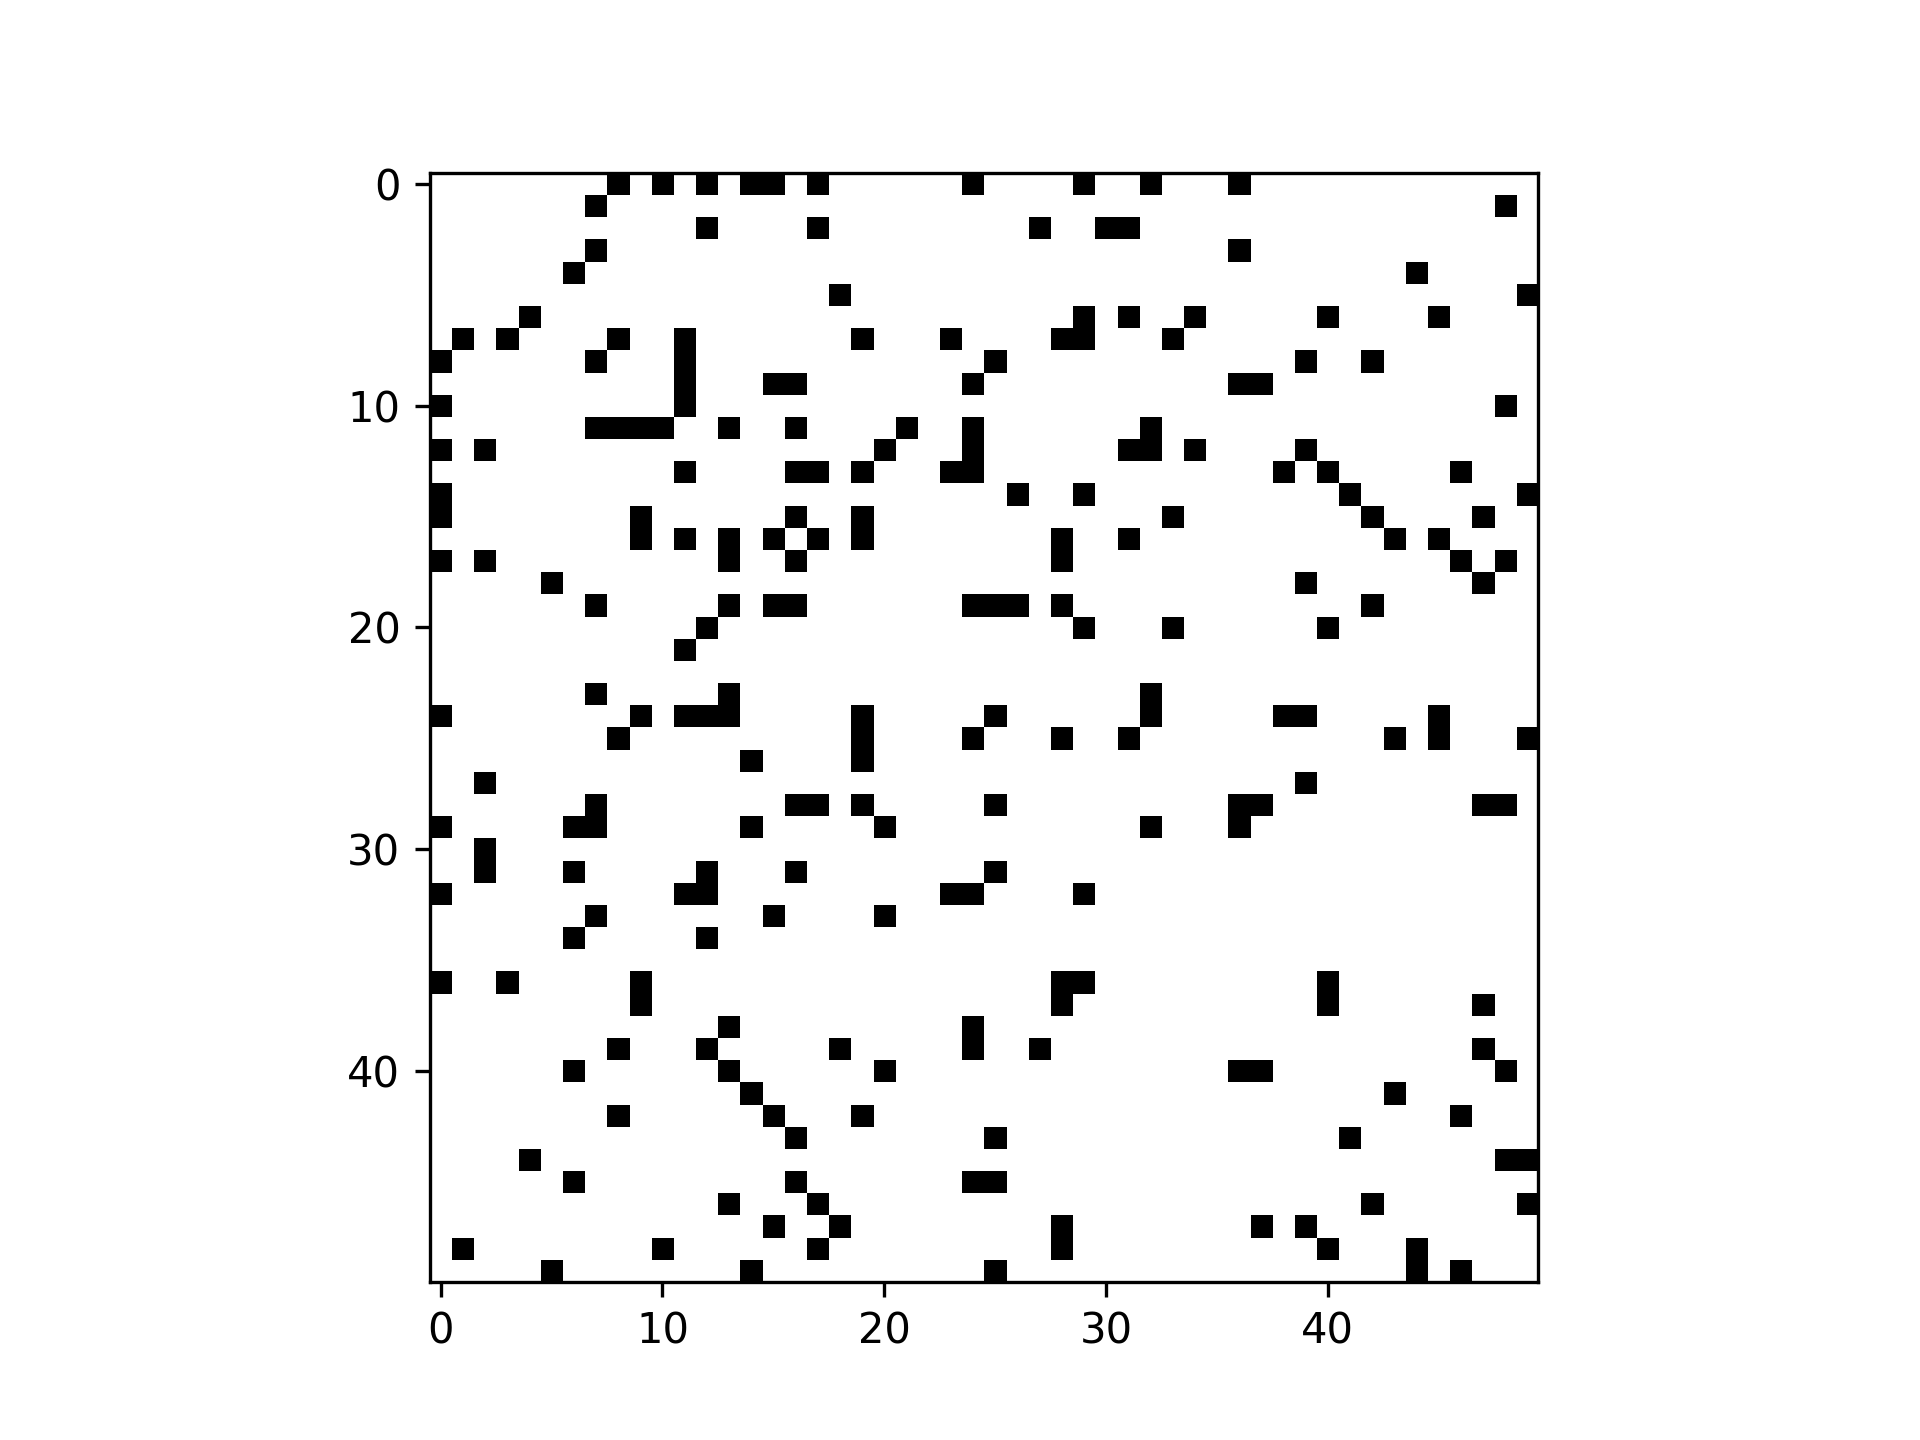

In [3]:
Y, X, probas_true = simulate_network_rw(
    n_nodes=50, n_time_steps=56, density=0.1, sigma=0.01,
    random_state=2398)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

0.1964190476190477


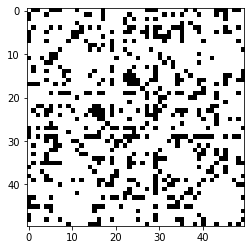

In [2]:
k_steps = 5
n_time_steps = 100

Y, X, probas_true = simulate_network_gp(
    n_nodes=50, n_time_steps=n_time_steps + k_steps, density=0.2, length_scale=3, 
    random_state=4)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

In [130]:
np.sqrt((X[0,0] ** 2).sum())

0.4926735392608698

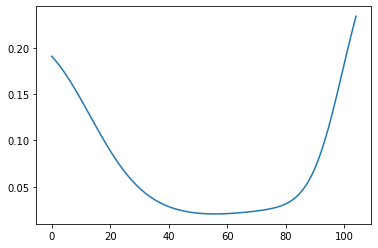

In [33]:
plt.plot(probas_true[:, 0, 10])

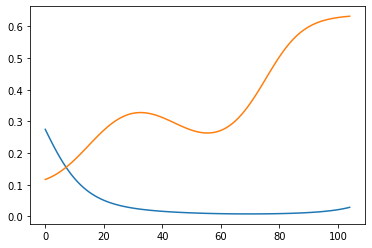

In [32]:
plt.plot(X[:, 1], '-')
#plt.plot(X[:, 2], '-')

In [22]:
rdpg = DynamicRDPG(n_features=2, rw_order=2, prior_std=10.)
rdpg.sample(Y[:-k_steps], n_burnin=200, n_samples=200)

100%|████████████████████████████████████████████████████████████████████████████████| 400/400 [00:51<00:00,  7.76it/s]


<Axes: ylabel='Density'>

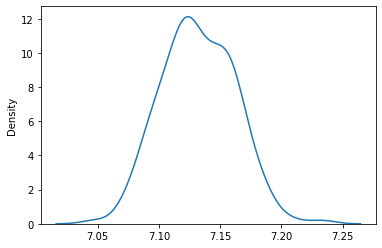

In [17]:
sns.kdeplot(rdpg.samples_['scale'])

In [18]:
rdpg.waic()

17173.327387999365

In [6]:
rdpg.waic()

12010.41843206162

In [9]:
rdpg.waic()

12062.541011337868

In [36]:
rdpg.dic()

18584.31275010249

In [34]:
rdpg.dic()

18622.2208804648

In [27]:
rdpg.dic()

22680.358229007816

In [44]:
rdpg.waic()

18475.86310699238

In [5]:
n_params = np.prod(rdpg.X_.shape) + rdpg.sigma_.shape[0]
log_lik = -0.5 * np.sum((rdpg.y_vec_ - rdpg.probas_) ** 2)
-2 * log_lik + 2 * n_params

54256.64085536256

In [53]:
n_params = np.prod(rdpg.X_.shape) + rdpg.sigma_.shape[0]
log_lik = -0.5 * np.sum((rdpg.y_vec_ - rdpg.probas_) ** 2)
-2 * log_lik + 2 * n_params

63361.494273946686

In [55]:
n_params = np.prod(rdpg.X_.shape) + rdpg.sigma_.shape[0]
log_lik = -0.5 * np.sum((rdpg.y_vec_ - rdpg.probas_) ** 2)
-2 * log_lik + 2 * n_params

73343.58517306966

In [45]:
k_steps

5

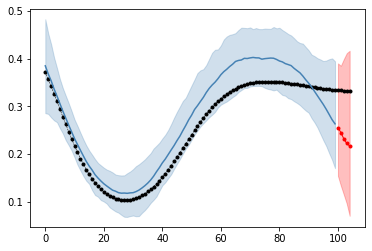

In [12]:
i, j = 30, 5

plt.plot(probas_true[:, i, j], 'k.--', lw=0.5)

n_time_steps, n_nodes, _ = rdpg.X_.shape
probas_pred = rdpg.predict(n_samples=1000)
cis = np.quantile(probas_pred[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
plt.plot(np.arange(n_time_steps), cis[1], color='steelblue')
plt.fill_between(np.arange(n_time_steps), cis[0], cis[2], color='steelblue', alpha=0.25)

probas_forecast = rdpg.forecast(k_steps=k_steps, n_samples=1000)
cis = np.quantile(probas_forecast[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
ts = np.arange(n_time_steps, n_time_steps + k_steps)
plt.plot(ts, cis[1], '.-', color='red', lw=1)
plt.fill_between(ts, cis[0], cis[2], color='red', alpha=0.25)
#plt.ylim(0, 1)

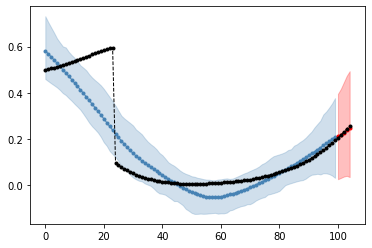

In [19]:
from scipy.linalg import orthogonal_procrustes

idx = 5


#print(np.sqrt(dase.sigma_[idx]))
X_est = rdpg.X_.copy()#np.mean(dase.samples_['X'], axis=0)
X_true = X.copy()
for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_true[t], X_est[t])
    X_true[t] = X_true[t] @ R

#for t in range(len(Y)-k_steps, len(Y)):
#    R, _ = orthogonal_procrustes(X_true[t], X_est[-1])
#    X_true[t] = X_true[t] @ R
    

cis = np.quantile(rdpg.samples_['X'][:, :, idx], q=[0.025, 0.975], axis=0)
#plt.plot(X_est[:, idx, 1], '-', color='darkorange', lw=2)
plt.plot(X_est[:, idx, 0], '.-', color='steelblue', lw=1)
#plt.fill_between(np.arange(len(Y)-1), cis[0, :, 1], cis[1, :, 1], color='darkorange', alpha=0.25)
plt.fill_between(np.arange(len(Y)-k_steps), cis[0, :, 0], cis[1, :, 0], color='steelblue', alpha=0.25)

samples = rdpg.forecast_positions(k_steps=k_steps, n_samples=200)
cis = np.quantile(samples, q=[0.025,0.5, 0.975], axis=0)
X_forecast = cis[1]
for k, t in enumerate(range(len(Y)-k_steps, len(Y))):
    R, _ = orthogonal_procrustes(X_true[t], X_forecast[k])
    X_true[t] = X_true[t] @ R
    
plt.plot(np.arange(X_est.shape[0], X_est.shape[0] + k_steps), X_forecast[:, idx, 0], '.-', color='red', lw=1)
plt.fill_between(np.arange(X_est.shape[0], X_est.shape[0] + k_steps), 
                 cis[0, :, idx, 0], cis[2, :, idx, 0], 
                 color='red', alpha=0.25)

plt.plot(X_true[:, idx, 0], '.--', lw=1, color='k')

0.7497814025214227


0.006919844173080482

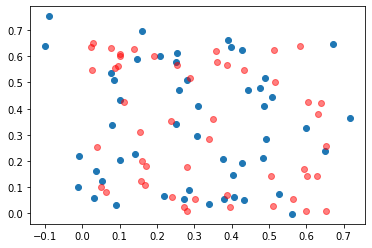

In [20]:
from scipy.linalg import orthogonal_procrustes
from sklearn.metrics import roc_auc_score

t = -1
X_rdpg = rdpg.X_[t]
R, _ = orthogonal_procrustes(X_rdpg, X[t])
X_rdpg = X_rdpg @ R
plt.scatter(X_rdpg[:, 0], X_rdpg[:, 1])
plt.scatter(X[t][:, 0], X[t][:, 1], c='red', alpha=0.5)

subdiag = np.tril_indices_from(Y[t], k=-1)

print(roc_auc_score(Y[t][subdiag], rdpg.probas_[t]))
np.mean((X_rdpg - X[t]) ** 2)

In [21]:
from scipy.linalg import orthogonal_procrustes

X_pred = rdpg.X_.copy()
for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_pred[t], X[t])
    X_pred[t] = X_pred[t] @ R
    
print(rdpg.auc_)
r_rdpg = np.mean((X_pred - X[:-k_steps]) ** 2)
r_rdpg

0.7510476080415698


0.004827239663089959

In [9]:
import scipy.sparse as sp
from sklearn.decomposition import TruncatedSVD

# unfolded adjacency spectral embedding
n_nodes, _ = Y[0].shape
A = sp.csr_array(np.hstack([Yt.toarray() for Yt in Y[:-k_steps]]))
u, s, vh= sp.linalg.svds(A, k=2)
X_uase = (vh.T[:, ::-1] * np.sqrt(s)[::-1]).reshape(len(Y[:-k_steps]), n_nodes, 2)

for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_uase[t], X[t])
    X_uase[t] = X_uase[t] @ R


np.mean((X_uase - X[:-k_steps]) ** 2)

0.08020121891853492

In [44]:
from graspologic.embed import AdjacencySpectralEmbed as ASE
from dynrdpg.dynrdpg import calculate_auc

proba_ase= []
X_ase = []
for t in range(len(Y)-k_steps):
    subdiag = np.tril_indices(Y[t].shape[0], k=-1)
    ase = ASE(n_components=2)
    X_ase.append(ase.fit_transform(Y[t]))
    R, _ = orthogonal_procrustes(X_ase[t], X[t])
    X_ase[t] = X_ase[t] @ R
    proba_ase.append(np.clip((X_ase[t] @ X_ase[t].T)[subdiag], 0, 1))

X_ase = np.stack(X_ase)
proba_ase = np.stack(proba_ase)

print(calculate_auc(rdpg.y_vec_, proba_ase))
r_ase = np.mean((X_ase - X[:-k_steps]) ** 2)# / np.mean(X ** 2))
r_ase

0.6848491444291205


/Users/joshua/.pyenv/versions/stats/lib/python3.10/site-packages/graspologic/embed/base.py:199: UserWarning: Input graph is not fully connected. Results may notbe optimal. You can compute the largest connected component byusing ``graspologic.utils.largest_connected_component``.
  warnings.warn(msg, UserWarning)


0.07285978605530902

In [45]:
from graspologic.embed import MultipleASE as MASE

X_mase = MASE(n_components=2).fit_transform(Y[:-k_steps])
X_aligned = []
for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_mase, X[t])
    X_aligned.append(X_mase @ R)
X_aligned = np.stack(X_aligned)

np.mean((X_aligned - X[:-k_steps]) ** 2)

0.09313773952497663

In [46]:
from graspologic.embed import OmnibusEmbed as OMNI

X_omni = OMNI(n_components=2).fit_transform(Y[:-k_steps])
for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_omni[t], X[t])
    X_omni[t] = X_omni[t] @ R
    
np.mean((X_omni - X[:-k_steps]) ** 2)

0.014782887210889141

## Forecast

In [47]:
from sklearn.metrics import roc_auc_score, log_loss

subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = rdpg.forecast(k_steps=k_steps, n_samples=1000).mean(axis=0)[-1][subdiag]
y_true = Y[-1].toarray()[subdiag]

print(roc_auc_score(y_true, y_pred))
print(log_loss(y_true, y_pred))
print(np.mean((probas_true[-1][subdiag] - y_pred) ** 2))

0.7426948697159028
0.45443854799534833
0.004502544202080804


In [48]:
subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = Y[-k_steps-1].toarray()[subdiag]
y_true = Y[-1].toarray()[subdiag]

print(roc_auc_score(y_true, y_pred))
log_loss(y_true, y_pred)
print(np.mean((probas_true[-1][subdiag] - y_pred) ** 2) / np.mean(probas_true[-1][subdiag] ** 2))

0.5517559339279184
2.41512903120527


In [49]:
from graspologic.embed import AdjacencySpectralEmbed as ASE

ase = ASE(n_components=2)
X_ase = ase.fit_transform(Y[-k_steps])
y_pred = np.clip(X_ase @ X_ase.T, 0, 1)[subdiag]
y_true = Y[-1].toarray()[subdiag]

print(roc_auc_score(y_true, y_pred))
print(log_loss(y_true, y_pred))
print(np.mean((probas_true[-1][subdiag] - y_pred) ** 2))

0.6727973323158613
0.820856754217099
0.019290864769194886


/Users/joshua/.pyenv/versions/stats/lib/python3.10/site-packages/graspologic/embed/base.py:199: UserWarning: Input graph is not fully connected. Results may notbe optimal. You can compute the largest connected component byusing ``graspologic.utils.largest_connected_component``.
  warnings.warn(msg, UserWarning)


In [50]:
from graspologic.embed import OmnibusEmbed as OMNI

omni = OMNI(n_components=2)
X_omni = omni.fit_transform(Y[:-k_steps])
y_pred = np.clip(X_omni[-1] @ X_omni[-1].T, 0, 1)[subdiag]
y_true = Y[-1].toarray()[subdiag]

print(roc_auc_score(y_true, y_pred))
print(log_loss(y_true, y_pred))
print(np.mean((probas_true[-1][subdiag] - y_pred) ** 2))

0.692012050682819
0.4784585327591552
0.01014570964699123


In [51]:
from graspologic.embed import MultipleASE as MASE
from sklearn.metrics import roc_auc_score

subdiag = np.tril_indices(Y[0].shape[0], k=-1)
mase = MASE(n_components=2).fit(Y[:-k_steps])
X_mase = mase.latent_left_
R = mase.scores_[-1]
y_pred_mase = np.clip(X_mase @ R @ X_mase.T, 0, 1)[subdiag]
y_true = Y[-1].toarray()[subdiag]

print(roc_auc_score(y_true, y_pred))
print(np.mean((probas_true[-1][subdiag] - y_pred_mase) ** 2))

0.692012050682819
0.015939750688167047


<Axes: ylabel='Count'>

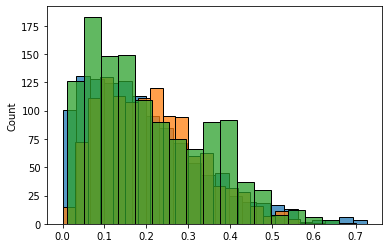

In [52]:
sns.histplot(y_pred_mase)
sns.histplot(y_pred)
sns.histplot(probas_true[-1][subdiag])

In [30]:
from graspologic.embed import OmnibusEmbed as OMNI

X_omni = OMNI(n_components=2).fit_transform(Y[:-6])
y_pred = np.clip(X_omni[-1] @ X_omni[-1].T, 0, 1)[subdiag]
y_true = Y[-1].toarray()[subdiag]

print(roc_auc_score(y_true, y_pred))
print(log_loss(y_true, y_pred))
print(np.mean((probas_true[-1][subdiag] - y_pred) ** 2))

0.6922754502372663
0.5579211760747692
0.01725118365237671
